# Lewis Signalling Game — Results

Load a CSV produced by `game_server.py` and visualise:
1. **Learning curve** — reward over rounds
2. **Signalling system** — the state→signal and signal→action mappings that emerged

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# ── Change this to your CSV filename ──────────────────────────────────────────
CSV_FILE = "results_test-1780909433_20260608_110359.csv"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_FILE)
print(df.head(10).to_string(index=False))
print(f"\nRounds: {len(df)}   Accuracy: {df['reward'].mean():.1%}")

 round  state  signal  action  reward
     0      0       2       1       0
     1      0       0       0       1
     2      3       3       3       1
     3      2       2       2       1
     4      3       3       3       1
     5      0       2       0       1
     6      2       3       0       0
     7      0       2       0       1
     8      3       3       3       1
     9      3       3       3       1

Rounds: 10   Accuracy: 80.0%


## Learning curve

Raw reward per round (0 or 1) and a rolling mean showing whether the agents converge.

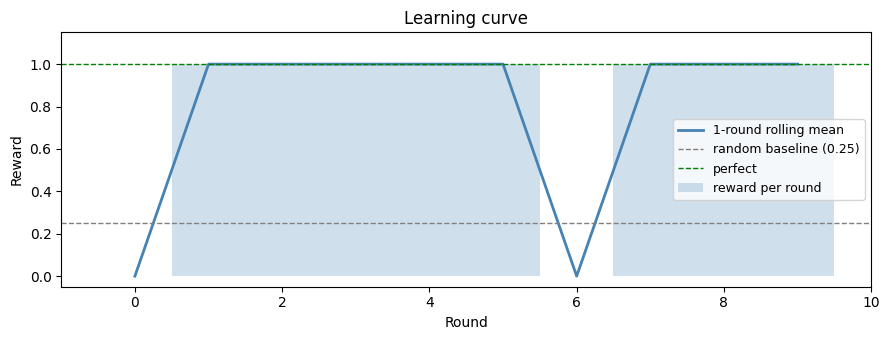

In [3]:
WINDOW = max(1, len(df) // 10)   # ~10 % of total rounds

rolling = df["reward"].rolling(WINDOW, min_periods=1).mean()
random_baseline = 1 / df[["state", "action"]].nunique().max()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(df["round"], df["reward"], color="steelblue", alpha=0.25, width=1, label="reward per round")
ax.plot(df["round"], rolling, color="steelblue", linewidth=2,
        label=f"{WINDOW}-round rolling mean")
ax.axhline(random_baseline, color="gray",  linestyle="--", linewidth=1,
           label=f"random baseline ({random_baseline:.2f})")
ax.axhline(1.0, color="green", linestyle="--", linewidth=1, label="perfect")
ax.set(xlabel="Round", ylabel="Reward", title="Learning curve", ylim=(-0.05, 1.15))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Emergent signalling system

Each heatmap is a **normalised frequency matrix** — how often the agents paired each row with each column across all rounds.

- **Sender** (left): rows = world states, columns = signals sent  
- **Receiver** (right): rows = signals received, columns = actions taken

A strong diagonal (or any consistent permutation) means a stable signalling convention emerged.

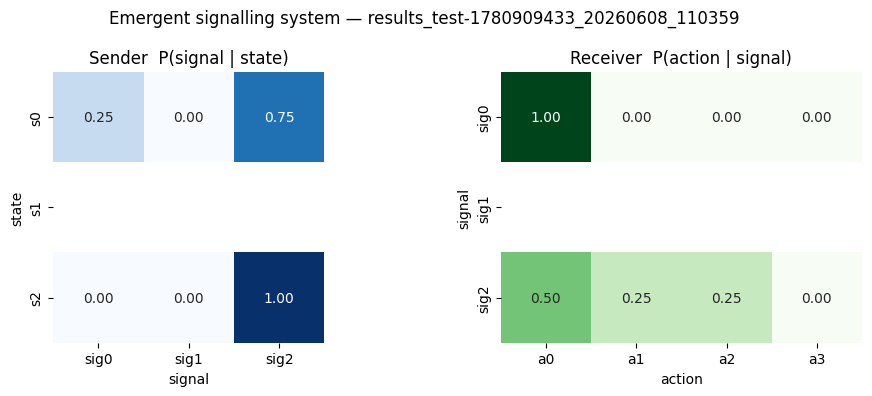

In [4]:
n_states   = df["state"].nunique()
n_signals  = df["signal"].nunique()
n_actions  = df["action"].nunique()

# Sender: P(signal | state)
sender_counts = (
    df.groupby(["state", "signal"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(n_states), columns=range(n_signals), fill_value=0)
)
sender_probs = sender_counts.div(sender_counts.sum(axis=1), axis=0)

# Receiver: P(action | signal)
receiver_counts = (
    df.groupby(["signal", "action"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(n_signals), columns=range(n_actions), fill_value=0)
)
receiver_probs = receiver_counts.div(receiver_counts.sum(axis=1), axis=0)

fig, (ax_s, ax_r) = plt.subplots(1, 2, figsize=(10, 4))
kw = dict(annot=True, fmt=".2f", cbar=False, vmin=0, vmax=1, square=True)

sns.heatmap(sender_probs,
            xticklabels=[f"sig{i}" for i in range(n_signals)],
            yticklabels=[f"s{i}"   for i in range(n_states)],
            cmap="Blues", ax=ax_s, **kw)
ax_s.set(title="Sender  P(signal | state)", xlabel="signal", ylabel="state")

sns.heatmap(receiver_probs,
            xticklabels=[f"a{i}"   for i in range(n_actions)],
            yticklabels=[f"sig{i}" for i in range(n_signals)],
            cmap="Greens", ax=ax_r, **kw)
ax_r.set(title="Receiver  P(action | signal)", xlabel="action", ylabel="signal")

plt.suptitle(f"Emergent signalling system — {Path(CSV_FILE).stem}", fontsize=12)
plt.tight_layout()
plt.show()

## Summary